## Build a Basic Chatbot with Langgraph ( Graph API )

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
    
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages : Annotated[list,add_messages] 

graph_builder =  StateGraph[State]

In [3]:
graph_builder

langgraph.graph.state.StateGraph[__main__.State]

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()


True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model = "openai/gpt-oss-20b")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000244C680D0F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000244C680D000>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

graph_builder.add_node("llmchatbot",chatbot) # Adding node 

graph_builder.add_edge(START, "llmchatbot") # Adding Edge from start to llmchatbot
graph_builder.add_edge("llmchatbot",END) # Adding Edge from llmchatbot to end

graph = graph_builder.compile() # Compiling the graph

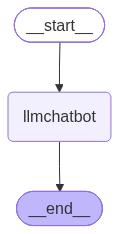

In [9]:
# Visualizing the graph

from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({"messages":"Hi"})

In [11]:
response["messages"][-1].content

'Hello! 👋 How can I help you today?'

# Chatbot With Tools 

In [12]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is Langgraph?")

{'query': 'what is Langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. Within LangGraph, the “state” feature serves as a memory bank that records and tracks all the valuable information processed by the AI system. It’s similar to a digital notebook where the system captures and upd

In [19]:
def multiply(a: int, b: int) -> int:
    """Multiply two integers"""
    return a * b

In [20]:
tools = [tool, multiply]

In [21]:
llm_with_tools = llm.bind_tools(tools)

In [22]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000244C680D0F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000244C680D000>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': '

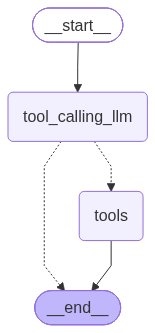

In [23]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If latest message from assistant is tool call, then go to tools node 
    # If latest message from assistant is not tool call, then go to end node
    tools_condition
)
builder.add_edge("tools",END)

# Compile the graph
graph = builder.compile()

from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
response = graph.invoke({"messages":"what is Langgraph?"})

In [26]:
response['messages'][-1].content

'{"query": "LangGraph framework LLM graph-based state management", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ai.plainenglish.io/ai-agents-xii-langgraph-graph-based-framework-b7b74e1fa5df", "title": "AI Agents XII — LangGraph graph-based framework", "content": "LangGraph is a graph-based framework built on top of LangChain for orchestrating complex AI workflows and multi-agent systems. It lets developers define stateful graphs where nodes are computation steps (e.g. LLM calls, tools, or arbitrary Python functions) and edges control the flow (fixed or conditional). Each graph has a shared state (typically a TypedDict schema) that nodes read and update.Unlike traditional LangChain chains (directed acyclic graphs), LangGraph explicitly supports loops and [...] LangGraph provides a powerful, low-level framework for composing LLM-powered applications as stateful graphs. Its core modules (`StateGraph`, nodes, edges, commands, etc.) let you build s

In [27]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is Langgraph?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_fd6fefc1-292a-452f-9889-43cf81cd353d)
 Call ID: fc_fd6fefc1-292a-452f-9889-43cf81cd353d
  Args:
    query: LangGraph framework LLM graph-based state management
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "LangGraph framework LLM graph-based state management", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ai.plainenglish.io/ai-agents-xii-langgraph-graph-based-framework-b7b74e1fa5df", "title": "AI Agents XII — LangGraph graph-based framework", "content": "LangGraph is a graph-based framework built on top of LangChain for orchestrating complex AI workflows and multi-agent systems. It lets developers define stateful graphs where nodes are computati

In [28]:
response = graph.invoke({"messages":"what is 2 multiplied by 6?"})

In [29]:
response['messages'][-1].content

'2 multiplied by 6 equals **12**.'

In [30]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 6?
================================== Ai Message ==================================

2 multiplied by 6 equals **12**.
